# Exploring GESLA Sea-Level Records

This notebook finds the tide-gauge station nearest to Newport, Oregon, downloads its sea-level record, and plots the observations.

- Data source: [GESLA downloads](https://gesla.org/).
- Data access: the [UHSLC ERDDAP table](https://uhslc.soest.hawaii.edu/erddap/tabledap/global_hourly_gesla.html).

In [1]:
from IPython.display import display

from utils.gesla import (
    download_sea_level_data,
    find_nearby_stations,
    plot_sea_level,
    save_sea_level_data,
)


REFERENCE_LATITUDE = 44.75
REFERENCE_LONGITUDE = -124
START_DATE = None  # Set ISO UTC dates to limit the downloaded period.
END_DATE = None

## Find Nearby Stations

First, download the station catalog and calculate each station's distance from Newport. The catalog response has no header row, so column names are supplied when it is read. Distance is calculated with the Haversine formula; longitude differences are wrapped so the calculation also works across the 0°/360° meridian.

In [2]:
stations = find_nearby_stations(REFERENCE_LATITUDE, REFERENCE_LONGITUDE)

display(
    stations[
        [
            "station_name",
            "agency_id",
            "station_code",
            "latitude",
            "longitude",
            "distance_km",
        ]
    ]
)

nearest_station = stations.iloc[0]
print(
    f"Selected station: {nearest_station['station_name']} "
    f"({nearest_station['agency_id']}, {nearest_station['station_code']})"
)
print(f"Distance from Newport: {nearest_station['distance_km']:.2f} km")

,station_name,agency_id,station_code,latitude,longitude,distance_km
0,South_Beach,NOAA,9435380,44.62540,235.9551,14.302364
1,South_Beach_OR,UHSLC_FD,592,44.62500,235.9570,14.309033
2,South_Beach_OR,UHSLC_RQ,592A,44.62500,235.9570,14.309033
3,Chinook_Bend,NOAA,9435992,44.88000,236.0364,14.737756
4,Weiser_Point,NOAA,9435308,44.59330,235.9920,17.435749
5,Cascade_Head,NOAA,9436381,45.04794,235.9927,33.134451
6,Waldport,NOAA,9434939,44.43436,235.9419,35.397854
7,Nestucca_Bay,NOAA,9436641,45.16100,236.0620,45.960836
8,Dick_Point,NOAA,9437381,45.48170,236.0980,81.724012
9,Florence_Uscg_Pier,NOAA,9434098,44.00210,235.8770,83.735376


Selected station: South_Beach (NOAA, 9435380)
Distance from Newport: 14.30 km


## Download the Time Series

The unique `record_id` selects the station's time series. `flag1` and `flag2` are quality flags provided by GESLA. `flag1` describes quality-control status; `flag2` marks each observation as `use` (1) or `do not use` (0). We keep both columns in the saved NetCDF file and use `flag2 == 1` when plotting.

In [3]:
sea_level_data = download_sea_level_data(
    record_id=str(nearest_station["record_id"]),
    start_date=START_DATE,
    end_date=END_DATE,
)

print(f"Downloaded observations: {len(sea_level_data):,}")
print(
    "Record period: "
    f"{sea_level_data['time'].min()} to {sea_level_data['time'].max()}"
)
display(sea_level_data.head())

Downloaded observations: 520,823
Record period: 1967-01-01 01:00:00+00:00 to 2026-05-31 23:00:00+00:00


,sea_level,time,flag1,flag2,record_id
0,NaN,1967-01-01 01:00:00+00:00,5,0,south_beach-9435380-usa-noaa
1,NaN,1967-01-01 02:00:00+00:00,5,0,south_beach-9435380-usa-noaa
2,NaN,1967-01-01 03:00:00+00:00,5,0,south_beach-9435380-usa-noaa
3,NaN,1967-01-01 04:00:00+00:00,5,0,south_beach-9435380-usa-noaa
4,NaN,1967-01-01 05:00:00+00:00,5,0,south_beach-9435380-usa-noaa


## Plot and Save the Observations

The plot includes only observations with a valid sea-level value and GESLA's `flag2` set to `1`. The NetCDF file (saved to `outputs/`) keeps every downloaded row and both original quality flags, with station metadata stored as global attributes.

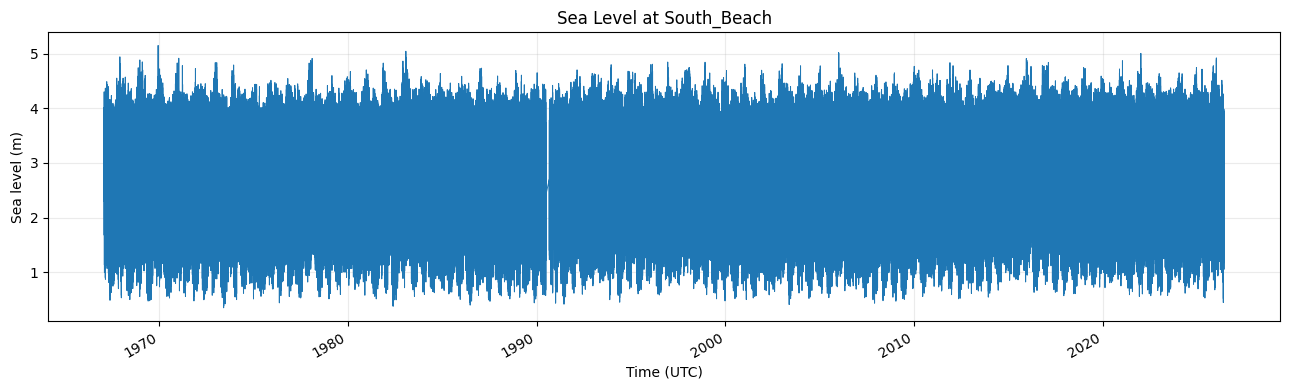

Saved 520,823 observations to: /lustre/geocean/WORK/users/ortizanguloj/personal/COURSES/BlueMath_Course_Corvallis/toolkit/data/outputs/GESLA_South_Beach_9435380_NOAA.nc


In [4]:
plot_sea_level(sea_level_data, nearest_station["station_name"])

output_path = save_sea_level_data(sea_level_data, nearest_station)
print(f"Saved {len(sea_level_data):,} observations to: {output_path.resolve()}")

## Data Use and Attribution

Before using or redistributing the data, review the [GESLA license](https://gesla787883612.wordpress.com/license/). For publications, GESLA requests citations to Haigh et al. (2023), Woodworth et al. (2017), and Caldwell et al. (2015), and acknowledgement of the Joint Archive for Sea Level / University of Hawaii Sea Level Center (JASL/UHSLC). See the [GESLA bibliography](https://gesla787883612.wordpress.com/bibliography/) for bibliographic details.